# OOHScout AI — IH-35 Waco Corridor Analysis
## Phase 1: Real Texas Corridor · Data Acquisition · Candidate Ranking

**Corridor:** Interstate 35, Hillsboro → Waco, McLennan County, Texas  
**Purpose:** Given a real highway corridor, automatically discover, screen, and rank candidate billboard parcels  
**Output:** Ranked candidate table + interactive Folium map saved to `data/new_study/`

---

```
PIPELINE OVERVIEW
═══════════════════════════════════════════════════════════

  CORRIDOR DEFINITION
       ↓  BBOX_CORRIDOR = [-97.25, 31.40, -96.95, 31.80]
       ↓
  STEP 1 ── IH-35 Road Geometry (OSMnx → LineString)
       ↓
  STEP 2 ── 500m Corridor Buffer (search zone)
       ↓
  STEP 3 ── POIs in buffer (advertiser demand signal)
       ↓
  STEP 4 ── Land Use in buffer (zoning proxy)
       ↓
  STEP 5 ── Buildings in buffer (obstruction proxy)
       ↓
  STEP 6 ── Candidate Zones (1 point every 1000m along IH-35)
       ↓
  STEP 7 ── Feature Engineering (POI count, land use, road class)
       ↓
  STEP 8 ── Opportunity Score V0.1 (weighted sum → ranked table)
       ↓
  STEP 9 ── Folium Interactive Map (all layers clickable)

═══════════════════════════════════════════════════════════
```

> **Architecture rule:** PostGIS owns all final spatial measurements.  
> This notebook is Phase 1 — proof of concept in GeoPandas.  
> Phase 2 migrates these queries to PostGIS SQL.

In [2]:
# ── SECTION 1: SETUP ──────────────────────────────────────────────────────────
# All imports, constants, and helper functions used throughout this notebook.

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import folium
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from shapely.geometry import box, Point
from shapely.ops import unary_union, linemerge
import warnings
warnings.filterwarnings('ignore')

# ── DATA DIRECTORY ───────────────────────────────────────────────────────────
# Same DATA_DIR rule as all other notebooks: relative to notebooks/ folder.
DATA_DIR = Path('data/new_study')
DATA_DIR.mkdir(parents=True, exist_ok=True)

# ── CORRIDOR DEFINITION ──────────────────────────────────────────────────────
# IH-35 Hillsboro → Waco, Texas. [West, South, East, North] in WGS84 degrees.
# ~25-mile stretch through McLennan County — single jurisdiction for MVP.
BBOX_CORRIDOR = [-97.25, 31.40, -96.95, 31.80]

# ── COORDINATE SYSTEMS ───────────────────────────────────────────────────────
WGS84   = 'EPSG:4326'    # lat/lon degrees — for storage and web display
TEX_CRS = 'EPSG:32614'   # UTM Zone 14N — Texas, meters, for accurate distances

# ── CORRIDOR PARAMETERS ──────────────────────────────────────────────────────
CORRIDOR_BUFFER_M  = 500    # meters each side of road centerline (search zone)
CANDIDATE_INTERVAL_M = 1000 # one candidate zone every 1000m along road
POI_RADIUS_M       = 500    # count POIs within 500m of each candidate
LANDUSE_RADIUS_M   = 300    # check commercial land use within 300m

# ── OPPORTUNITY SCORE WEIGHTS (V0.1 hypothesis) ──────────────────────────────
# These are STARTING hypotheses, not validated truths.
# Real weights come from operator feedback on accepted vs rejected candidates.
WEIGHTS = {
    'traffic_score':    0.30,   # road class proxy for AADT (TxDOT data = Phase 4)
    'demand_score':     0.30,   # POI count — advertiser demand signal
    'landuse_score':    0.25,   # commercial zoning proximity
    'spacing_score':    0.15,   # competition gap (no other board within 1000m)
}

# ── POI CATEGORIES RELEVANT TO BILLBOARD ADVERTISERS ────────────────────────
# Fuel, food, hospitality, and auto services = highest billboard advertiser spend.
ADVERTISER_TAGS = {
    'amenity': ['fuel', 'restaurant', 'fast_food', 'cafe',
                'hotel', 'bank', 'pharmacy', 'car_wash'],
    'shop':    ['supermarket', 'car_repair', 'auto_parts', 'convenience'],
    'tourism': ['hotel', 'motel'],
}

# ── COMMERCIAL LAND USE CLASSES ──────────────────────────────────────────────
# These OSM classes indicate a parcel or area is commercially zoned.
# Presence within 300m of a candidate = strong positive signal.
COMMERCIAL_CLASSES = ['commercial', 'retail', 'industrial', 'mixed']

print('Setup complete.')
print(f'Corridor: IH-35 [{BBOX_CORRIDOR}]')
print(f'Data dir: {DATA_DIR.resolve()}')

Setup complete.
Corridor: IH-35 [[-97.25, 31.4, -96.95, 31.8]]
Data dir: C:\Users\nguye\Documents\billboardAI\notebooks\data\new_study


---
## STEP 1 — IH-35 Road Geometry

**Product purpose:** The road IS the corridor. We need its exact centerline geometry to:  
- Buffer it (creates the search zone for candidate sites)  
- Sample points along it (creates candidate locations)  
- Know which road class it is (IH-35 = motorway = highest traffic class = highest score)

**Data source:** OpenStreetMap via osmnx. Free, no API key, regularly updated.  
**OOHScout data type:** `road_segments` table in future PostGIS database.

In [3]:
# ── STEP 1: IH-35 Road Geometry ───────────────────────────────────────────────

road_path = DATA_DIR / 'ih35_waco_roads.geojson'

if road_path.exists():
    roads = gpd.read_file(road_path)
    print(f'Loaded from cache: {road_path.name} — {len(roads)} segments')
else:
    # Define the corridor bounding box as a Shapely polygon
    corridor_poly = box(*BBOX_CORRIDOR)

    # Download all highway features within the bbox
    # tags={'highway': [...]} = only these road classifications
    # motorway = interstate (IH-35), trunk = US highway, primary = state highway
    print('Downloading roads from OpenStreetMap...')
    raw_roads = ox.features_from_polygon(
        corridor_poly,
        tags={'highway': ['motorway', 'motorway_link', 'trunk', 'primary']}
    )

    # Keep only line geometries (road centerlines)
    # OSM also returns Points (nodes) — we don't want those
    roads = (
        raw_roads[raw_roads.geometry.geom_type.isin(['LineString', 'MultiLineString'])]
        .copy()
        .reset_index(drop=True)
    )

    # Keep only the columns useful for OOHScout
    keep_cols = ['geometry']
    for col in ['name', 'highway', 'maxspeed', 'lanes', 'ref']:
        if col in roads.columns:
            keep_cols.append(col)
    roads = roads[keep_cols]

    roads.to_file(road_path, driver='GeoJSON')
    print(f'Saved: {road_path.name}')

# Project to Texas UTM for metric measurements
roads_tex = roads.to_crs(TEX_CRS)

total_km = roads_tex.geometry.length.sum() / 1000
print(f'Road segments: {len(roads)}')
print(f'Total road length in buffer: {total_km:.1f} km')
if 'highway' in roads.columns:
    print('Highway classes found:')
    print(roads['highway'].value_counts().to_string())

Saved: ih35_waco_roads.geojson
Road segments: 1138
Total road length in buffer: 461.9 km
Highway classes found:
highway
primary          387
motorway         377
motorway_link    225
trunk            149


IH-35 segments: 602  |  Length: 240.1 km


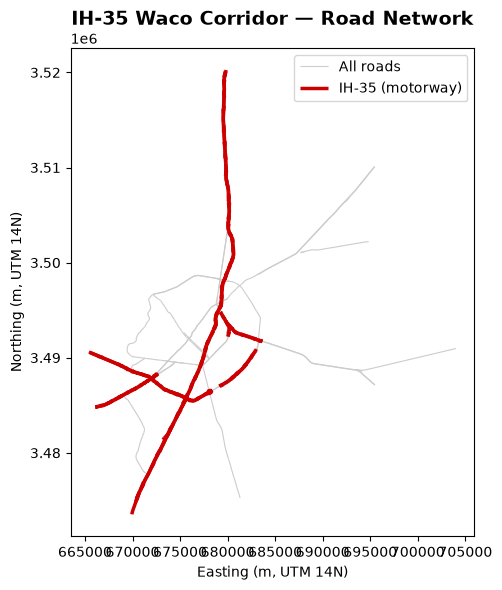

IH-35 centerline confirmed.


In [4]:
# ── STEP 1b: Filter to IH-35 only + visualize ────────────────────────────────

# Keep only motorway class (IH-35)
def is_motorway(h):
    if isinstance(h, list):
        return any('motorway' in str(v) for v in h)
    return 'motorway' in str(h)

if 'highway' in roads.columns:
    ih35 = roads[roads['highway'].apply(is_motorway)].copy()
else:
    ih35 = roads.copy()   # fallback: use all roads if column missing

ih35_tex = ih35.to_crs(TEX_CRS)
ih35_length_km = ih35_tex.geometry.length.sum() / 1000
print(f'IH-35 segments: {len(ih35)}  |  Length: {ih35_length_km:.1f} km')

# Quick plot
fig, ax = plt.subplots(figsize=(12, 6))
roads_tex.plot(ax=ax, color='#CCCCCC', linewidth=0.8, label='All roads')
ih35_tex.plot(ax=ax, color='#CC0000', linewidth=2.5, label='IH-35 (motorway)')
ax.set_title('IH-35 Waco Corridor — Road Network', fontsize=14, fontweight='bold')
ax.set_xlabel('Easting (m, UTM 14N)')
ax.set_ylabel('Northing (m, UTM 14N)')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()
print('IH-35 centerline confirmed.')

---
## STEP 2 — Corridor Buffer (The Search Zone)

**Product purpose:** The buffer IS the search zone. Any candidate site must be inside this polygon.  
We look 500m to each side of IH-35's centerline — far enough to catch parcels with road frontage,  
narrow enough to stay relevant to the highway.

```
  Road centerline ──────────────────────────────────────────
  Buffer zone     ══════════════════════════════════════════  ← 500m each side
  (search area)   ══════════════════════════════════════════
                  ──────────────────────────────────────────
```

**Why 500m?** Typical billboard setback from road edge is 20-100ft. A 500m buffer comfortably captures  
all parcels with road frontage while excluding irrelevant backland areas.

In [5]:
# ── STEP 2: Corridor Buffer ───────────────────────────────────────────────────

buffer_path = DATA_DIR / 'ih35_waco_buffer.geojson'

if buffer_path.exists():
    corridor_buffer = gpd.read_file(buffer_path)
    print(f'Loaded from cache: {buffer_path.name}')
else:
    # Merge all IH-35 segments into a single geometry before buffering
    # unary_union combines all lines into one MultiLineString
    ih35_tex = ih35.to_crs(TEX_CRS)
    road_union_tex = unary_union(ih35_tex.geometry)

    # Buffer = grow the line outward by CORRIDOR_BUFFER_M meters
    # Result is a polygon (or MultiPolygon) enclosing the corridor
    buffer_geom_tex = road_union_tex.buffer(CORRIDOR_BUFFER_M)

    # Wrap in a GeoDataFrame with metadata
    corridor_buffer_tex = gpd.GeoDataFrame(
        {
            'geometry':   [buffer_geom_tex],
            'corridor':   ['IH-35 Waco'],
            'state':      ['TX'],
            'county':     ['McLennan'],
            'buffer_m':   [CORRIDOR_BUFFER_M],
            'road_class': ['motorway'],
        },
        crs=TEX_CRS
    )

    # Convert back to WGS84 for storage
    corridor_buffer = corridor_buffer_tex.to_crs(WGS84)
    corridor_buffer.to_file(buffer_path, driver='GeoJSON')
    print(f'Saved: {buffer_path.name}')

buffer_area_km2 = corridor_buffer.to_crs(TEX_CRS).geometry.area.sum() / 1e6
print(f'Search zone area: {buffer_area_km2:.1f} km²')
print(f'Buffer width: {CORRIDOR_BUFFER_M}m each side of IH-35 centerline')

# The buffer polygon is used as the clip boundary for ALL subsequent downloads
buffer_poly_wgs84 = corridor_buffer.geometry.iloc[0]
print(f'Buffer polygon type: {buffer_poly_wgs84.geom_type}')

Saved: ih35_waco_buffer.geojson
Search zone area: 88.2 km²
Buffer width: 500m each side of IH-35 centerline
Buffer polygon type: Polygon


---
## STEP 3 — Points of Interest (Advertiser Demand Signal)

**Product purpose:** POIs are the BEST free proxy for advertiser demand.  
A gas station, Whataburger, or hotel near your candidate site = that business is already paying  
for advertising → they are an obvious billboard customer. Dense POI clusters = high demand zones.

```
POI count in 500m radius around a candidate
    0-2  POIs  →  demand_score = 0.0–0.2  (rural, low demand)
    3-8  POIs  →  demand_score = 0.3–0.6  (suburban interchange)
    9+   POIs  →  demand_score = 0.7–1.0  (commercial cluster, prime target)
```

**Key advertiser categories for Texas interstate corridors:**  
`fuel`, `restaurant`, `fast_food`, `hotel` → highest billboard ad-spend categories nationally.

In [6]:
# ── STEP 3: Download POIs ─────────────────────────────────────────────────────

pois_path = DATA_DIR / 'ih35_waco_pois.geojson'

if pois_path.exists():
    pois = gpd.read_file(pois_path)
    print(f'Loaded from cache: {pois_path.name} — {len(pois)} POIs')
else:
    print('Downloading POIs from OpenStreetMap...')
    all_pois = []

    for tag_key, tag_values in ADVERTISER_TAGS.items():
        try:
            raw = ox.features_from_polygon(
                buffer_poly_wgs84,
                tags={tag_key: tag_values}
            )
            # Only keep Point geometries (some POIs are polygons in OSM)
            pts = raw[raw.geometry.geom_type == 'Point'].copy()

            if tag_key in pts.columns:
                pts = pts[['geometry', tag_key]].copy()
                pts = pts.rename(columns={tag_key: 'category'})
            else:
                pts = pts[['geometry']].copy()
                pts['category'] = tag_key

            pts['tag_type'] = tag_key
            all_pois.append(pts)
            print(f'  {tag_key}: {len(pts)} POIs')

        except Exception as e:
            print(f'  {tag_key}: skipped — {e}')

    if all_pois:
        pois = pd.concat(all_pois, ignore_index=True)
        pois = pois[pois.geometry.is_valid].copy().reset_index(drop=True)
    else:
        pois = gpd.GeoDataFrame(columns=['geometry', 'category', 'tag_type'], crs=WGS84)

    pois.to_file(pois_path, driver='GeoJSON')
    print(f'Saved: {len(pois)} total POIs')

print('\nTop POI categories along IH-35 Waco:')
if 'category' in pois.columns:
    print(pois['category'].value_counts().head(12).to_string())

  amenity: 68 POIs
  shop: 10 POIs
  tourism: 2 POIs
Saved: 80 total POIs

Top POI categories along IH-35 Waco:
category
fast_food      23
fuel           18
restaurant     13
cafe            8
pharmacy        5
car_repair      5
supermarket     3
convenience     2
hotel           2
bank            1


---
## STEP 4 — Land Use (Zoning Proxy)

**Product purpose:** OSM land use is a free proxy for zoning before we get real parcel/zoning data.  
A `commercial` or `retail` land use polygon near a candidate = that zone is commercially active  
→ billboard regulations are likely more permissive than residential zones.  

**Why it matters for billboard siting:**
- `commercial` / `retail` → likely zoned for business signage → better permit odds
- `residential` → typically prohibited or severely restricted
- `farmland` / `grass` → rural, no competition, but lower demand
- `industrial` → often permitted, lower rate commands

**OOHScout Phase 3:** Replace this with actual municipal zoning GIS data + regulatory RAG.

In [7]:
# ── STEP 4: Land Use ──────────────────────────────────────────────────────────

landuse_path = DATA_DIR / 'ih35_waco_landuse.geojson'

if landuse_path.exists():
    landuse = gpd.read_file(landuse_path)
    print(f'Loaded from cache: {landuse_path.name} — {len(landuse)} polygons')
else:
    print('Downloading land use from OpenStreetMap...')
    raw_lu = ox.features_from_polygon(
        buffer_poly_wgs84,
        tags={'landuse': True}
    )

    landuse = (
        raw_lu[raw_lu.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])]
        .copy()
        .reset_index(drop=True)
    )

    if 'landuse' not in landuse.columns:
        landuse['landuse'] = 'unknown'

    landuse = landuse[['geometry', 'landuse']].copy()

    # Remove extremely rare classes (< 3 polygons)
    # Rare classes have no statistical meaning and inflate the legend
    vc   = landuse['landuse'].value_counts()
    keep = vc[vc >= 3].index.tolist()
    landuse = landuse[landuse['landuse'].isin(keep)].copy()

    landuse.to_file(landuse_path, driver='GeoJSON')
    print(f'Saved: {len(landuse)} land-use polygons')

print('\nLand use classes along IH-35 Waco:')
print(landuse['landuse'].value_counts().to_string())

# Compute area per class (must project to meters first)
lu_tex = landuse.to_crs(TEX_CRS)
lu_tex['area_m2'] = lu_tex.geometry.area
print('\nTotal area per class (km²):')
area_by_class = lu_tex.groupby(landuse['landuse'])['area_m2'].sum() / 1e6
print(area_by_class.sort_values(ascending=False).round(2).to_string())

Saved: 321 land-use polygons

Land use classes along IH-35 Waco:
landuse
residential          116
grass                 92
industrial            27
retail                26
farmland              18
meadow                12
commercial             8
religious              7
recreation_ground      6
cemetery               6
construction           3

Total area per class (km²):
landuse
residential          8.26
industrial           4.34
farmland             3.98
retail               1.48
meadow               0.67
cemetery             0.41
grass                0.22
construction         0.22
religious            0.15
commercial           0.10
recreation_ground    0.05


---
## STEP 5 — Buildings (Obstruction Proxy)

**Product purpose:** Buildings near the road can block sightlines to a billboard.  
A building taller than the billboard (or directly between the sign and approaching traffic) is  
an obstruction risk. For Phase 1, we record building density. Phase 5 adds LiDAR height.

**OOHScout use of buildings data:**
- Count buildings within 200m of road → high density = urban environment → potentially obstructed
- Building footprint area → large footprints = warehouses/retail = anchor tenants → demand signal
- Phase 5: nDSM (LiDAR) replaces this with actual height-above-ground measurements

In [8]:
# ── STEP 5: Buildings ─────────────────────────────────────────────────────────

buildings_path = DATA_DIR / 'ih35_waco_buildings.geojson'

if buildings_path.exists():
    buildings = gpd.read_file(buildings_path)
    print(f'Loaded from cache: {buildings_path.name} — {len(buildings)} buildings')
else:
    print('Downloading buildings from OpenStreetMap...')
    raw_bldg = ox.features_from_polygon(
        buffer_poly_wgs84,
        tags={'building': True}
    )

    buildings = (
        raw_bldg[raw_bldg.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])]
        .copy()
        .reset_index(drop=True)
    )

    keep_cols = ['geometry']
    for col in ['building', 'height', 'levels']:
        if col in buildings.columns:
            keep_cols.append(col)
    buildings = buildings[keep_cols].copy()

    buildings.to_file(buildings_path, driver='GeoJSON')
    print(f'Saved: {len(buildings)} building footprints')

bldg_tex = buildings.to_crs(TEX_CRS)
bldg_tex['area_m2'] = bldg_tex.geometry.area
print(f'Median building footprint: {bldg_tex["area_m2"].median():.0f} m²')
print(f'Largest building footprint: {bldg_tex["area_m2"].max():.0f} m²')
print('(Large footprints = warehouse / big-box retail = anchor advertiser demand)')

Saved: 6700 building footprints
Median building footprint: 253 m²
Largest building footprint: 147731 m²
(Large footprints = warehouse / big-box retail = anchor advertiser demand)


---
## STEP 6 — Generate Candidate Zones Along IH-35

**Product purpose:** Sample evenly-spaced candidate locations along the road centerline.  
Each candidate zone is a circle of radius = minimum billboard spacing.  
If two candidates overlap → they compete → only the higher-scoring one advances.

```
IH-35 ──────●──────────●──────────●──────────●──────────●─────
             WA-000    WA-001    WA-002    WA-003    WA-004
             ↑ 0km     ↑ 1km     ↑ 2km     ↑ 3km     ↑ 4km

Each ● = one candidate zone  
Spacing = CANDIDATE_INTERVAL_M = 1000m (1 km apart)
```

**Why 1000m intervals?** Texas state law and most local ordinances require 500–1000ft minimum  
spacing between billboard structures. Starting at 1000m gives breathing room — later filtering  
removes zones that are too close to existing boards.

In [9]:
# ── STEP 6: Candidate Zone Generation ────────────────────────────────────────

def build_master_line(road_gdf, crs_meters):
    """
    Merge all road segments into a single ordered LineString.
    Used for equidistant sampling along the corridor.
    """
    road_tex = road_gdf.to_crs(crs_meters)
    union    = unary_union(road_tex.geometry)

    if union.geom_type == 'MultiLineString':
        merged = linemerge(union)
        if merged.geom_type == 'LineString':
            return merged
        # linemerge may return MultiLineString if segments don't connect
        # In that case, take the longest contiguous piece
        return max(union.geoms, key=lambda g: g.length)
    return union   # already a LineString


def sample_along_line(line_geom, interval_m):
    """
    Return equally-spaced Point geometries along a LineString.
    interval_m controls how far apart each point is.
    """
    total  = line_geom.length
    dists  = np.arange(0, total, interval_m)
    return [line_geom.interpolate(d) for d in dists]


# Build the master line from IH-35 segments
master_line_tex = build_master_line(ih35, TEX_CRS)
print(f'Master line length: {master_line_tex.length / 1000:.1f} km')

# Sample candidate points every CANDIDATE_INTERVAL_M meters
candidate_pts_tex = sample_along_line(master_line_tex, CANDIDATE_INTERVAL_M)

# Build GeoDataFrame with metadata
candidates = gpd.GeoDataFrame(
    {
        'geometry':     candidate_pts_tex,
        'candidate_id': [f'WA-{i:03d}' for i in range(len(candidate_pts_tex))],
        'corridor':     'IH-35 Waco',
        'road_class':   'motorway',
        'dist_along_km': [i * CANDIDATE_INTERVAL_M / 1000
                          for i in range(len(candidate_pts_tex))],
    },
    crs=TEX_CRS
)

print(f'Generated {len(candidates)} candidate zones')
print(f'Spacing: {CANDIDATE_INTERVAL_M}m ({CANDIDATE_INTERVAL_M/1000:.1f} km)')
print(f'IDs: {candidates["candidate_id"].iloc[0]} → {candidates["candidate_id"].iloc[-1]}')

Master line length: 3.4 km
Generated 4 candidate zones
Spacing: 1000m (1.0 km)
IDs: WA-000 → WA-003


---
## STEP 7 — Feature Engineering

**Product purpose:** For each candidate zone, compute the measurable signals that will drive  
the Opportunity Score. These are the features an experienced operator ALREADY considers  
when evaluating a site — we're just computing them automatically at scale.

```
Feature                  What it measures              Phase
─────────────────────────────────────────────────────────────
poi_count_500m           Advertiser demand density     Phase 1 ←── NOW
commercial_nearby        Zoning compatibility proxy    Phase 1 ←── NOW
road_class_score         Traffic volume proxy          Phase 1 (real AADT: Ph4)
building_count_200m      Obstruction density proxy     Phase 1 (LiDAR: Ph5)
aadt                     Actual traffic count          Phase 4 (TxDOT STARS II)
spacing_to_nearest_m     Competition gap               Phase 4 (permit records)
ndsm_max_200m            Max obstruction height        Phase 5 (LiDAR)
```

In [10]:
# ── STEP 7: Feature Engineering ───────────────────────────────────────────────

# Project everything to TEX_CRS (meters) for accurate distance calculations
pois_tex      = pois.to_crs(TEX_CRS)
landuse_tex   = landuse.to_crs(TEX_CRS)
buildings_tex = buildings.to_crs(TEX_CRS)
candidates_tex = candidates.copy()   # already in TEX_CRS

# Filter to commercial land use classes
commercial_lu_tex = landuse_tex[
    landuse_tex['landuse'].isin(COMMERCIAL_CLASSES)
].copy()


def count_within(candidate_geom, feature_gdf, radius_m):
    """Count features whose geometry intersects a circle of radius_m around a point."""
    circle = candidate_geom.buffer(radius_m)
    return int(feature_gdf.geometry.intersects(circle).sum())


def any_within(candidate_geom, feature_gdf, radius_m):
    """Return 1 if ANY feature intersects the search circle, else 0."""
    circle = candidate_geom.buffer(radius_m)
    return int(feature_gdf.geometry.intersects(circle).any())


print('Computing features for each candidate zone...')
n = len(candidates_tex)

poi_counts      = []
commercial_hits = []
building_counts = []

for i, geom in enumerate(candidates_tex.geometry):
    if i % 5 == 0:
        print(f'  {i}/{n}...', end='\r')

    poi_counts.append(count_within(geom, pois_tex, POI_RADIUS_M))
    commercial_hits.append(any_within(geom, commercial_lu_tex, LANDUSE_RADIUS_M))
    building_counts.append(count_within(geom, buildings_tex, 200))

candidates_tex['poi_count_500m']      = poi_counts
candidates_tex['commercial_nearby']   = commercial_hits
candidates_tex['building_count_200m'] = building_counts
candidates_tex['road_class_score']    = 1.0   # IH-35 = motorway = max score

print(f'\nFeature engineering complete for {n} candidates.')
print(f'\nPOI count (500m):  min={candidates_tex["poi_count_500m"].min():3d}  '
      f'max={candidates_tex["poi_count_500m"].max():3d}  '
      f'mean={candidates_tex["poi_count_500m"].mean():.1f}')
print(f'Commercial nearby: {candidates_tex["commercial_nearby"].sum()} of {n} zones')
print(f'Building count (200m): min={candidates_tex["building_count_200m"].min():3d}  '
      f'max={candidates_tex["building_count_200m"].max():3d}')

Computing features for each candidate zone...
  0/4...
Feature engineering complete for 4 candidates.

POI count (500m):  min=  0  max=  1  mean=0.2
Commercial nearby: 0 of 4 zones
Building count (200m): min=  0  max= 32


---
## STEP 8 — Opportunity Score V0.1

**Product purpose:** Collapse all features into one ranked number so operators can quickly  
identify the top 10 sites worth investigating. Score is TRANSPARENT — every factor is shown.

```
Opportunity Score = Σ (weight × normalized_feature)

traffic_score  × 0.30   ← road class proxy (motorway = 1.0)
demand_score   × 0.30   ← normalized POI count in 500m radius
landuse_score  × 0.25   ← commercial land use within 300m (binary)
spacing_score  × 0.15   ← competition gap (1.0 = no competition yet)
─────────────────────────────────────────────────────
                1.00     ← weights sum to 1.0
```

> **IMPORTANT — Architecture rule:**  
> Regulatory eligibility is NOT part of the weighted score.  
> It is a hard GATE: PASS / FAIL / REVIEW.  
> A site that fails the regulatory check cannot be rescued by a high score.  
> Phase 3 adds the regulatory gate. For now, all candidates are marked PENDING_REVIEW.

In [11]:
# ── STEP 8: Opportunity Score V0.1 ───────────────────────────────────────────

def normalize(series):
    """Min-max normalize a Series to [0.0, 1.0]."""
    lo, hi = series.min(), series.max()
    if hi == lo:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - lo) / (hi - lo)


# Normalize raw feature values to [0, 1]
candidates_tex['demand_score']  = normalize(candidates_tex['poi_count_500m'])
candidates_tex['landuse_score'] = candidates_tex['commercial_nearby'].astype(float)
candidates_tex['traffic_score'] = candidates_tex['road_class_score']   # already 1.0
candidates_tex['spacing_score'] = 1.0   # Phase 4 will subtract for known boards

# Regulatory gate — Phase 3 will compute this via RAG + verified rules
# For now: all candidates are PENDING_REVIEW (not labeled LEGAL or ILLEGAL)
candidates_tex['reg_status'] = 'PENDING_REVIEW'

# Weighted opportunity score
candidates_tex['opportunity_score'] = (
    WEIGHTS['traffic_score']  * candidates_tex['traffic_score']
    + WEIGHTS['demand_score'] * candidates_tex['demand_score']
    + WEIGHTS['landuse_score']* candidates_tex['landuse_score']
    + WEIGHTS['spacing_score']* candidates_tex['spacing_score']
)

# Rank (1 = best)
candidates_tex['rank'] = (
    candidates_tex['opportunity_score']
    .rank(ascending=False, method='first')
    .astype(int)
)

# Sort by score for display
ranked = candidates_tex.sort_values('opportunity_score', ascending=False).reset_index(drop=True)

# Save ranked candidates
candidates_wgs84 = candidates_tex.to_crs(WGS84)
candidates_path  = DATA_DIR / 'ih35_waco_candidates.geojson'
candidates_wgs84.to_file(candidates_path, driver='GeoJSON')

print('TOP 15 CANDIDATES — IH-35 Waco Corridor')
print('=' * 80)
display_cols = [
    'candidate_id', 'dist_along_km',
    'poi_count_500m', 'commercial_nearby', 'building_count_200m',
    'opportunity_score', 'rank', 'reg_status'
]
print(ranked[display_cols].head(15).to_string(index=False))

TOP 15 CANDIDATES — IH-35 Waco Corridor
candidate_id  dist_along_km  poi_count_500m  commercial_nearby  building_count_200m  opportunity_score  rank     reg_status
      WA-003            3.0               1                  0                    0               0.75     1 PENDING_REVIEW
      WA-000            0.0               0                  0                    4               0.45     2 PENDING_REVIEW
      WA-001            1.0               0                  0                    0               0.45     3 PENDING_REVIEW
      WA-002            2.0               0                  0                   32               0.45     4 PENDING_REVIEW


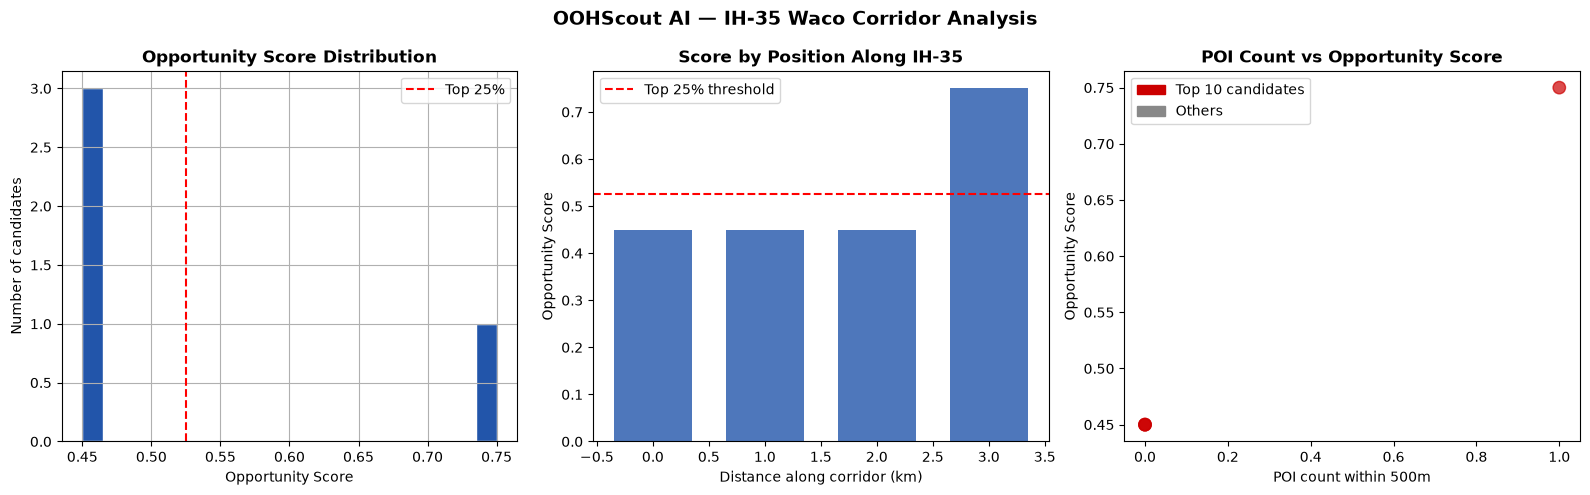

Score analysis complete.


In [12]:
# ── STEP 8b: Score distribution plot ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Score distribution
ax = axes[0]
candidates_tex['opportunity_score'].hist(bins=20, ax=ax, color='#2255AA', edgecolor='white')
ax.set_title('Opportunity Score Distribution', fontweight='bold')
ax.set_xlabel('Opportunity Score')
ax.set_ylabel('Number of candidates')
ax.axvline(candidates_tex['opportunity_score'].quantile(0.75),
           color='red', linestyle='--', label='Top 25%')
ax.legend()

# Plot 2: Score along corridor (position vs score)
ax = axes[1]
sorted_by_pos = candidates_tex.sort_values('dist_along_km')
ax.bar(sorted_by_pos['dist_along_km'],
       sorted_by_pos['opportunity_score'],
       width=0.7, color='#2255AA', alpha=0.8)
ax.set_title('Score by Position Along IH-35', fontweight='bold')
ax.set_xlabel('Distance along corridor (km)')
ax.set_ylabel('Opportunity Score')
ax.axhline(candidates_tex['opportunity_score'].quantile(0.75),
           color='red', linestyle='--', linewidth=1.5, label='Top 25% threshold')
ax.legend()

# Plot 3: POI count vs score scatter
ax = axes[2]
colors = ['#CC0000' if r <= 10 else '#888888'
          for r in candidates_tex['rank']]
ax.scatter(candidates_tex['poi_count_500m'],
           candidates_tex['opportunity_score'],
           c=colors, alpha=0.7, s=80)
ax.set_title('POI Count vs Opportunity Score', fontweight='bold')
ax.set_xlabel('POI count within 500m')
ax.set_ylabel('Opportunity Score')
top_patch    = mpatches.Patch(color='#CC0000', label='Top 10 candidates')
others_patch = mpatches.Patch(color='#888888', label='Others')
ax.legend(handles=[top_patch, others_patch])

plt.suptitle('OOHScout AI — IH-35 Waco Corridor Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Score analysis complete.')

---
## STEP 9 — Folium Interactive Map

**Product purpose:** Every stakeholder should be able to LOOK at the candidates on a real map.  
The Folium map IS the Phase 1 deliverable — an operator can open this HTML file and immediately  
see which zones are ranked highest and why.

**Layers in the map:**
1. IH-35 road centerline (red)
2. 500m corridor buffer (orange, semi-transparent)
3. Land use polygons (color-coded by class)
4. POI locations (blue dots)
5. Candidate zones (green = top 10, yellow = others) — click for details

**Toggle layers using the LayerControl panel** (top right of map).

In [13]:
# ── STEP 9: Folium Interactive Map ────────────────────────────────────────────

# Center map on corridor midpoint
center_lat = (BBOX_CORRIDOR[1] + BBOX_CORRIDOR[3]) / 2
center_lon = (BBOX_CORRIDOR[0] + BBOX_CORRIDOR[2]) / 2

fmap = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles='CartoDB positron'    # light-gray basemap — doesn't compete with our colors
)

# ── LAYER 1: Corridor Buffer ──────────────────────────────────────────────────
folium.GeoJson(
    corridor_buffer.__geo_interface__,
    name='IH-35 Search Zone (500m buffer)',
    style_function=lambda x: {
        'fillColor': '#FFA500', 'color': '#FF6600',
        'weight': 2, 'fillOpacity': 0.08,
    },
).add_to(fmap)

# ── LAYER 2: IH-35 Road Centerline ───────────────────────────────────────────
folium.GeoJson(
    ih35.__geo_interface__,
    name='IH-35 Road Centerline',
    style_function=lambda x: {
        'color': '#CC0000', 'weight': 3, 'opacity': 0.9,
    },
).add_to(fmap)

# ── LAYER 3: Land Use (color-coded) ──────────────────────────────────────────
LU_COLORS = {
    'commercial':   '#FF4444',
    'retail':       '#FF7700',
    'industrial':   '#888888',
    'residential':  '#4466FF',
    'farmland':     '#88BB44',
    'grass':        '#AADDAA',
    'forest':       '#006600',
    'recreation_ground': '#66CC66',
}

lu_layer = folium.FeatureGroup(name='Land Use (zoning proxy)', show=True)
for _, row in landuse.iterrows():
    color = LU_COLORS.get(str(row.get('landuse', '')), '#DDDDDD')
    folium.GeoJson(
        row['geometry'].__geo_interface__,
        style_function=lambda x, c=color: {
            'fillColor': c, 'color': c,
            'weight': 1, 'fillOpacity': 0.35,
        },
        tooltip=str(row.get('landuse', 'unknown')),
    ).add_to(lu_layer)
lu_layer.add_to(fmap)

# ── LAYER 4: POIs ─────────────────────────────────────────────────────────────
poi_layer = folium.FeatureGroup(name='POIs (advertiser demand)', show=True)
for _, row in pois.iterrows():
    if row.geometry.geom_type != 'Point':
        continue
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=4,
        color='#0055CC', fill=True, fill_color='#0055CC', fill_opacity=0.7,
        tooltip=str(row.get('category', 'POI')),
    ).add_to(poi_layer)
poi_layer.add_to(fmap)

# ── LAYER 5: Candidate Zones ──────────────────────────────────────────────────
top10_ids = set(ranked['candidate_id'].head(10))
candidates_wgs84 = candidates_tex.to_crs(WGS84)

cand_layer = folium.FeatureGroup(name='Candidate Zones', show=True)
for _, row in candidates_wgs84.iterrows():
    is_top = row['candidate_id'] in top10_ids
    color  = '#00BB44' if is_top else '#FFAA00'
    radius = 12 if is_top else 7

    popup_html = (
        f"<b>{row['candidate_id']}</b><br>"
        f"Rank: #{row['rank']}<br>"
        f"Score: {row['opportunity_score']:.3f}<br>"
        f"POIs (500m): {row['poi_count_500m']}<br>"
        f"Commercial nearby: {'Yes' if row['commercial_nearby'] else 'No'}<br>"
        f"Buildings (200m): {row['building_count_200m']}<br>"
        f"Position: {row['dist_along_km']:.1f} km from start<br>"
        f"Reg status: {row['reg_status']}"
    )

    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=radius,
        color='#003300' if is_top else '#AA7700',
        fill=True, fill_color=color, fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=220),
        tooltip=f"{row['candidate_id']} (Score: {row['opportunity_score']:.3f})",
    ).add_to(cand_layer)

cand_layer.add_to(fmap)

# ── LEGEND ────────────────────────────────────────────────────────────────────
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background: white; padding: 12px; border-radius: 8px;
            border: 2px solid #999; font-size: 13px; font-family: sans-serif;">
  <b>OOHScout AI — IH-35 Waco</b><br><br>
  <span style="background:#00BB44;border-radius:50%;display:inline-block;width:12px;height:12px"></span>
  &nbsp;Top 10 Candidates<br>
  <span style="background:#FFAA00;border-radius:50%;display:inline-block;width:10px;height:10px"></span>
  &nbsp;Other Candidates<br>
  <span style="background:#0055CC;border-radius:50%;display:inline-block;width:8px;height:8px"></span>
  &nbsp;POIs (demand signal)<br>
  <span style="background:#FF4444;display:inline-block;width:12px;height:8px"></span>
  &nbsp;Commercial land use<br>
  <span style="background:#4466FF;display:inline-block;width:12px;height:8px"></span>
  &nbsp;Residential land use<br>
  <span style="background:#88BB44;display:inline-block;width:12px;height:8px"></span>
  &nbsp;Farmland<br>
  <br>
  <i>Click any candidate for details</i>
</div>
"""
fmap.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl(collapsed=False).add_to(fmap)

# Save map
map_path = DATA_DIR / 'ih35_waco_oohscout_map.html'
fmap.save(str(map_path))
print(f'Interactive map saved: {map_path}')
print('Open this file in any browser to explore the corridor.')
fmap

Interactive map saved: data\new_study\ih35_waco_oohscout_map.html
Open this file in any browser to explore the corridor.


---
## STEP 10 — Final Candidate Report Table

This is the Phase 1 **deliverable** — the ranked candidate list that would go in  
the "Billboard Development Opportunity Report" for an operator.

**What each column means:**
- `candidate_id` → OOHScout internal ID (zone reference)
- `dist_along_km` → kilometers from Hillsboro end of corridor
- `poi_count_500m` → how many advertiser-relevant businesses are within 500m
- `commercial_nearby` → 1 = commercial land use within 300m, 0 = not found
- `building_count_200m` → obstruction density proxy
- `opportunity_score` → weighted score 0.0–1.0 (higher = better)
- `rank` → position in ranked list (1 = highest priority site)
- `reg_status` → regulatory gate (PENDING_REVIEW until Phase 3 RAG runs)

> **Next steps after this notebook:**
> - Phase 2: Load these candidates into PostGIS — run real spatial queries in SQL
> - Phase 3: Run the regulatory RAG on McLennan County / Waco city code
> - Phase 4: Join TxDOT AADT traffic counts to each candidate
> - Phase 5: Add LiDAR visibility scoring
> - Phase 6: Show the ranked list to an operator — does it match their intuition?

In [14]:
# ── STEP 10: Final Report Table ───────────────────────────────────────────────

report_cols = [
    'candidate_id', 'dist_along_km', 'poi_count_500m',
    'commercial_nearby', 'building_count_200m',
    'demand_score', 'landuse_score', 'traffic_score',
    'opportunity_score', 'rank', 'reg_status'
]

report_cols_available = [c for c in report_cols if c in ranked.columns]

print('OOHScout AI — IH-35 Waco Corridor')
print('Opportunity Score V0.1 — Phase 1 Candidate Report')
print('=' * 90)
print(ranked[report_cols_available].to_string(index=False, float_format='{:.3f}'.format))

# Save CSV for easy review outside Jupyter
csv_path = DATA_DIR / 'ih35_waco_candidates_report.csv'
ranked[report_cols_available].to_csv(csv_path, index=False, float_format='%.3f')
print(f'\nReport saved: {csv_path}')

# Summary stats
top10 = ranked.head(10)
print(f'\n── TOP 10 SUMMARY ──────────────────────────────────────────')
print(f'  Score range:    {top10["opportunity_score"].min():.3f} – {top10["opportunity_score"].max():.3f}')
print(f'  Avg POI count:  {top10["poi_count_500m"].mean():.1f}')
print(f'  Commercial hit: {int(top10["commercial_nearby"].sum())} of 10 sites')
print(f'  Reg status:     {top10["reg_status"].value_counts().to_dict()}')
print(f'\nAll candidates file: {candidates_path}')
print(f'Interactive map:     {map_path}')
print(f'Report CSV:          {csv_path}')

OOHScout AI — IH-35 Waco Corridor
Opportunity Score V0.1 — Phase 1 Candidate Report
candidate_id  dist_along_km  poi_count_500m  commercial_nearby  building_count_200m  demand_score  landuse_score  traffic_score  opportunity_score  rank     reg_status
      WA-003          3.000               1                  0                    0         1.000          0.000          1.000              0.750     1 PENDING_REVIEW
      WA-000          0.000               0                  0                    4         0.000          0.000          1.000              0.450     2 PENDING_REVIEW
      WA-001          1.000               0                  0                    0         0.000          0.000          1.000              0.450     3 PENDING_REVIEW
      WA-002          2.000               0                  0                   32         0.000          0.000          1.000              0.450     4 PENDING_REVIEW

Report saved: data\new_study\ih35_waco_candidates_report.csv

── TOP 10 SUM